[]

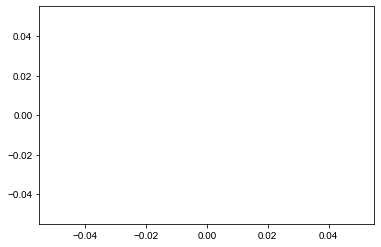

In [1]:
#!/usr/bin/env python3
"""
Date: Feb 28, 2025; Ammendament of Group 4 data date: Mar 13, 2025
Author: yying7@jh.edu

Analysis of Dataset on fixed shape and size cap with different gag density
Note: New version after reverting the incorrect energy force calculation PR

Geometry Information:

a=30 nm; b=30 nm (circular)

:wc -l mc_mesh_a30_b30d*

<-- GagSize = number of rows in file

 GagSize FileName               TrialGroup
     162 mc_mesh_a30_b30d10.csv 1
     112 mc_mesh_a30_b30d12.csv 2
      72 mc_mesh_a30_b30d15.csv 3
      45 mc_mesh_a30_b30d20.csv 4
      30 mc_mesh_a30_b30d25.csv 5
     241 mc_mesh_a30_b30d8.csv  0
     977 total

d10 means the mean distance between nearby gags is 1.0 * 4.7
d25 means the mean distance between nearby gags is 2.5 * 4.7
etc.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

import seaborn as sns
import os

plt.plot()
sns.set_context("talk")
plt.plot()

In [17]:
df_results = pd.read_csv("./results/results.csv")

# Reset column names
# EB: bending energy
# EA: area constraint energy
# ER: regularization energy (should converge to near 0)
# Etot: total energy
# MeanForce: mean force on every node
df_results.columns = ['FolderName', 'RelaxArea', 'EB', 'EA', 'ER', 'Etot', 'MeanForce']

# extracts the last two digits in the name,
# and save in TrialGroup and TrialNum respectively.
# e.g. _fixedmc_01, then TrialGroup is 0 and TrialNum is 1.
# Assuming df_results is already loaded
df_results['TrialGroup'] = df_results['FolderName'].apply(lambda x: int(x.split('_')[-1]) // 10)
df_results['TrialNum'] = df_results['FolderName'].apply(lambda x: int(x.split('_')[-1]) % 10)

# Define mapping of TrialGroup to GagSize and corresponding FileName patterns
# See Docstring above for more information
gag_info = {
    0: {"GagSize": 241, "FilePattern": "mc_mesh_a30_b30d8.csv"},
    1: {"GagSize": 162, "FilePattern": "mc_mesh_a30_b30d10.csv"},
    2: {"GagSize": 112, "FilePattern": "mc_mesh_a30_b30d12.csv"},
    3: {"GagSize": 72,  "FilePattern": "mc_mesh_a30_b30d15.csv"},
    4: {"GagSize": 45,  "FilePattern": "mc_mesh_a30_b30d20.csv"},
    5: {"GagSize": 30,  "FilePattern": "mc_mesh_a30_b30d25.csv"},
}

# Function to extract GagDistance from FilePattern
def get_gag_distance(file_pattern):
    import re
    match = re.search(r'd(\d+)', file_pattern)
    if match:
        return int(match.group(1)) / 10.0 * 4.7  # Convert dX to X * 4.7
    return None

# Assign GagSize and GagDistance based on TrialGroup
df_results["GagSize"] = df_results["TrialGroup"].map(lambda x: gag_info[x]["GagSize"] if x in gag_info else None)
df_results["GagDistance"] =\
    df_results["TrialGroup"].map(lambda x: get_gag_distance(gag_info[x]["FilePattern"]) if x in gag_info else None)

df_results.tail(50)

,FolderName,RelaxArea,EB,EA,ER,Etot,MeanForce,TrialGroup,TrialNum,GagSize,GagDistance
30,_fixedeb2_37,78000.0,248.195,0.006430,2.361810e-08,248.203,0.000827,3,7,72,7.05
31,_fixedeb2_38,78250.0,290.842,0.013657,2.184720e-24,290.861,0.000880,3,8,72,7.05
32,_fixedeb2_41,77500.0,290.336,0.010138,2.194550e-08,290.347,0.000827,4,1,45,9.40
33,_fixedeb2_42,77750.0,294.120,0.010539,6.461410e-08,294.132,0.000695,4,2,45,9.40
34,_fixedeb2_43,78000.0,297.716,0.010999,3.905260e-08,297.728,0.000720,4,3,45,9.40
35,_fixedeb2_44,78250.0,301.009,0.011348,3.962720e-08,301.022,0.000945,4,4,45,9.40
36,_fixedeb2_45,78500.0,318.476,0.013241,0.000000e+00,318.495,0.001020,4,5,45,9.40
37,_fixedeb2_46,78750.0,314.744,0.011727,0.000000e+00,314.761,0.000974,4,6,45,9.40
38,_fixedeb2_47,79000.0,325.551,0.014048,0.000000e+00,325.568,0.000988,4,7,45,9.40
39,_fixedeb2_48,79250.0,354.482,0.020591,0.000000e+00,354.507,0.001157,4,8,45,9.40


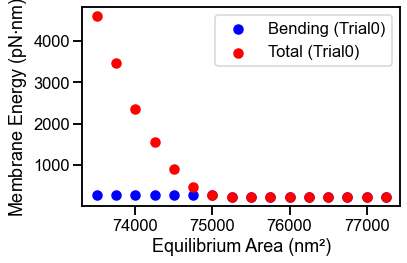

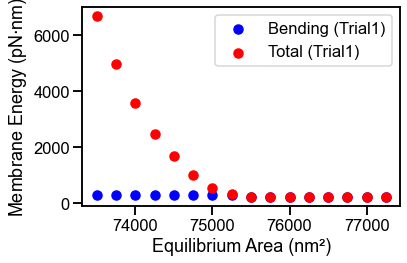

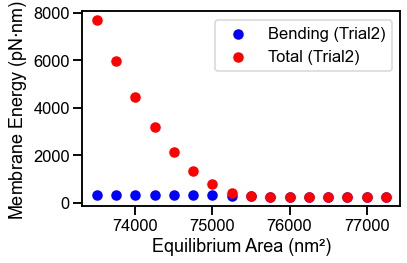

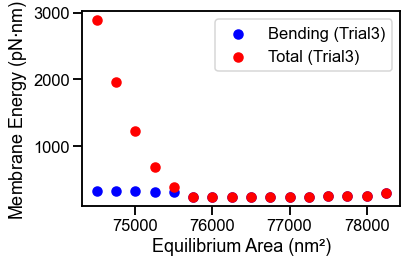

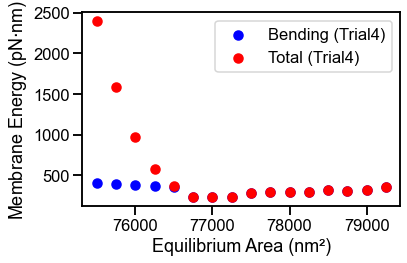

'./svg'

In [3]:
"""
For every trial group, draw a plot of EB on y-axis and RelaxArea on x-axis.
Set the axis label and tick font to Arial. Set x-axis name to Equilibrium Area (nm^2)
(the ^2 should be superscript) and y-axis name to Membrane Bending Energy (pN{dot}nm)
(the dot should be a dot product symbol). Save each plot with a distinct name as .svg
in the ./svg directory.

Repeat that process for Etot Membrane Total Energy (pN{dot}nm) versus RelaxArea
"""

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Unique trial groups
trial_groups = df_results['TrialGroup'].unique()

# Define superscript format for labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Membrane Energy (pN$\cdot$nm)"

# Generate plots for each trial group
for group in trial_groups:
    df_group = df_results[df_results['TrialGroup'] == group]

    # Plot EB vs RelaxArea
    plt.figure(figsize=(6, 4))
    plt.scatter(df_group['RelaxArea'], df_group['EB'], color='b', label=f'Bending (Trial{group})')

    # Plot Etot vs RelaxArea
    plt.scatter(df_group['RelaxArea'], df_group['Etot'], color='r', label=f'Total (Trial{group})')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'TrialGroup_{group}_EB_Etot_vs_RelaxArea.svg'), format='svg')
    plt.show()

# Notify user that the plots are saved
output_dir


In [4]:
"""
(1) group by GagDistance and calculate the minimum bending energy and total energy in each group
(2) in each group, use resampling to calculate error of MINIMUM.
    See the following function docstring for more information.
    
(3) Initiate a plot with two subplots. Plot minimum bending energy on y-axis
    and Gag-Distance on x-axis with a bar plot on the first subplot.
    Use a single-sided errorbar that only goes upwards to show the error of minimum.
(4) Repeat that for total energy on the second subplot.
"""

# Function to perform resampling to estimate error of minimum energy
def resampling_min_error(data, num_samples=100000, confidence=0.95):
    """
    Perform a bootstrap resampling test to estimate the error of the minimum energy in each GagDistance group.
    
    The process involves:
    - Randomly resampling (with replacement) the energy values in the group.
    - Computing the minimum energy for each resampled dataset.
    - Calculating the upper bound error based on a one-sided confidence interval.

    Args:
    - data: The energy values of a given group.
    - num_samples: Number of bootstrap samples to generate.
    - confidence: Confidence level for the upper bound error estimation.

    Returns:
    - The upper error estimate for the minimum energy.
    """
    min_values = []
    for _ in range(num_samples):
        resampled_data = np.random.choice(data, size=len(data), replace=True)
        min_values.append(np.min(resampled_data))
    
    #print(min_values)
    # Compute the one-sided error bound at the given confidence level
    error = np.percentile(min_values, (confidence) * 100) - np.min(data)
    #print(error)
    return error

[4.159 3.792 2.887 2.601 3.031]
[4.154 3.793 2.888 2.601 3.03 ]


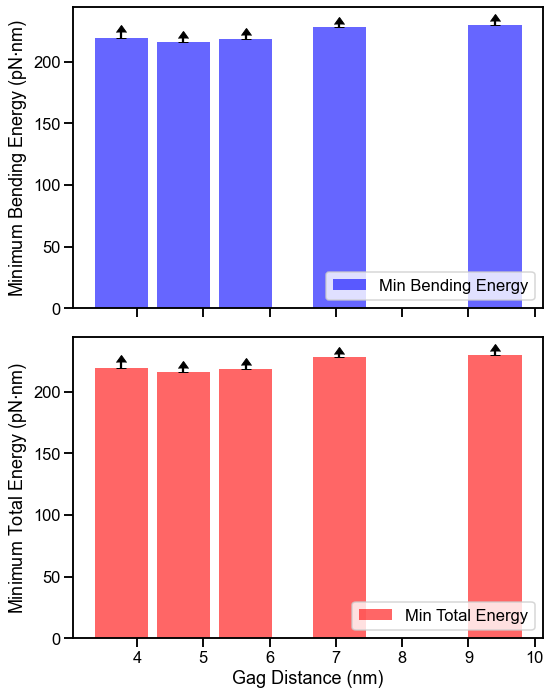

In [5]:
# Group by GagDistance and compute the minimum values
grouped_df = df_results.groupby("GagDistance").agg({"EB": "min", "Etot": "min"}).reset_index()

# Compute error estimates for minimum bending and total energy
error_eb = []
error_etot = []

for gag_dist in grouped_df["GagDistance"]:
    subset_eb = df_results[df_results["GagDistance"] == gag_dist]["EB"]
    subset_etot = df_results[df_results["GagDistance"] == gag_dist]["Etot"]
    
    error_eb.append(resampling_min_error(subset_eb))
    error_etot.append(resampling_min_error(subset_etot))

# Convert errors to numpy array
error_eb = np.array(error_eb)
print(error_eb)
error_etot = np.array(error_etot)
print(error_etot)

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# First subplot - Minimum Bending Energy
axes[0].bar(grouped_df["GagDistance"], grouped_df["EB"], color='blue', alpha=0.6, label="Min Bending Energy")
axes[0].errorbar(grouped_df["GagDistance"], grouped_df["EB"],
                 yerr=error_eb, fmt='none', ecolor='black', capsize=5, lolims=True)
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].legend()

# Second subplot - Minimum Total Energy
axes[1].bar(grouped_df["GagDistance"], grouped_df["Etot"], color='red', alpha=0.6, label="Min Total Energy")
axes[1].errorbar(grouped_df["GagDistance"], grouped_df["Etot"],
                 yerr=error_etot, fmt='none', ecolor='black', capsize=5, lolims=True)
axes[1].set_xlabel("Gag Distance (nm)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'All_{group}_EB_Etot_vs_Density_no_exclusion_ver.svg'), format='svg')
plt.show()



Calculate Theoretical minimum

0.8 * pi * kappa = 209.607058272

Add relaxation

8pikappa * (0.75) ^ 2 * 35.4^2 / (130^2 - 35.4^2)
  = (0.75) ^ 2 * 35.4^2 / (70.8^2 - 35.4^2) * 8 * 3.1415926 * 83.4
  = 393.013426
  
  = 87.0574665997
  
  296.664524872 pNnm


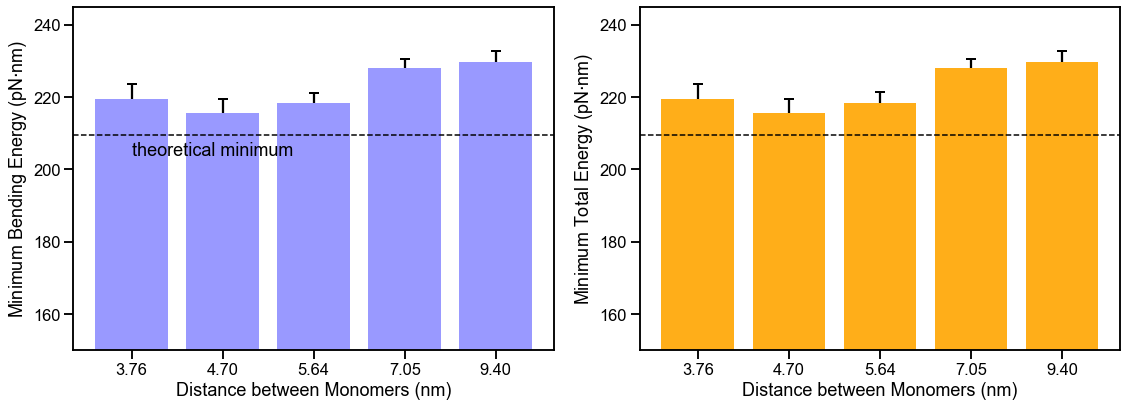

In [23]:

# Group by GagDistance and compute the minimum values
grouped_df = df_results.groupby("GagDistance").agg({"EB": "min", "Etot": "min"}).reset_index()

# Compute error estimates for minimum bending and total energy
error_eb = []
error_etot = []

for gag_dist in grouped_df["GagDistance"]:
    subset_eb = df_results[df_results["GagDistance"] == gag_dist]["EB"]
    subset_etot = df_results[df_results["GagDistance"] == gag_dist]["Etot"]
    
    error_eb.append(resampling_min_error(subset_eb))
    error_etot.append(resampling_min_error(subset_etot))

# Convert errors to numpy array
error_eb = np.array(error_eb)
error_etot = np.array(error_etot)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define colors
bending_energy_color = 'blue'
total_energy_color = 'orange'
horizontal_line_value = 209.607058272  # Theoretical minimum

# First subplot - Minimum Bending Energy
axes[0].bar(grouped_df["GagDistance"].astype(str).map(lambda x: f"{float(x):.2f}"),
            grouped_df["EB"], color=bending_energy_color,
            alpha=0.4, label="Min Bending Energy")
_,cl,_ = axes[0].errorbar(grouped_df["GagDistance"].astype(str).map(lambda x: f"{float(x):.2f}"),
                          grouped_df["EB"],
                 yerr=error_eb, fmt='none', ecolor='black', capsize=5, capthick=2, lolims=True)
cl[0].set_marker('_')
cl[1].set_marker('')
axes[0].set_xlabel("Distance between Monomers (nm)")
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].set_ylim(150, 245)  # Adjust y-axis range to start from 150
axes[0].text(0.0, horizontal_line_value - 2, "theoretical minimum", 
             color='black', fontsize=18, ha='left', va='top')

# Add horizontal line
axes[0].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)

# Second subplot - Minimum Total Energy
axes[1].bar(grouped_df["GagDistance"].astype(str).map(lambda x: f"{float(x):.2f}"),
            grouped_df["Etot"], color=total_energy_color,
            alpha=0.9, label="Min Total Energy")
_,cl,_=axes[1].errorbar(grouped_df["GagDistance"].astype(str).map(lambda x: f"{float(x):.2f}"),
                        grouped_df["Etot"],
                 yerr=error_etot, fmt='none', ecolor='black', capsize=5, capthick=2, lolims=True)
cl[0].set_marker('_')
cl[1].set_marker('')
axes[1].set_xlabel("Distance between Monomers (nm)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].set_ylim(150, 245)  # Adjust y-axis range to start from 150

# Add horizontal line
axes[1].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                         f'All_{group}_EB_Etot_vs_Density_no_exclusion_ver_add_minebline.svg'), format='svg')
plt.show()


In [24]:
grouped_df["Etot"]

0    219.458
1    215.658
2    218.389
3    228.066
4    229.836
Name: Etot, dtype: float64

#### 95% confidence interval error bar, acquired through bootstraop resampling of sample.

In [25]:
grouped_df["EB"]

0    219.434
1    215.651
2    218.382
3    228.059
4    229.824
Name: EB, dtype: float64

# Bootstrap comparison test for difference of minimum

In [7]:
import itertools
from scipy.stats import bootstrap

# Function to compute bootstrap p-value
def bootstrap_test(data1, data2, num_resamples=10000):
    """Performs a bootstrap hypothesis test on the difference of minimum."""
    observed_diff = np.min(data1) - np.min(data2)
    combined = np.concatenate([data1, data2])

    diffs = []
    for _ in range(num_resamples):
        np.random.shuffle(combined)
        resample1 = combined[:len(data1)]
        resample2 = combined[len(data1):]
        diffs.append(np.min(resample1) - np.min(resample2))

    p_value = np.mean(np.abs(diffs) >= np.abs(observed_diff))
    return p_value

# Group by GagDistance and compute the minimum values
grouped_df = df_results.groupby("GagDistance").agg({"EB": "min", "Etot": "min"}).reset_index()

# Compute error estimates for minimum bending and total energy
error_eb = []
error_etot = []

for gag_dist in grouped_df["GagDistance"]:
    subset_eb = df_results[df_results["GagDistance"] == gag_dist]["EB"]
    subset_etot = df_results[df_results["GagDistance"] == gag_dist]["Etot"]

    error_eb.append(np.std(subset_eb) / np.sqrt(len(subset_eb)))
    error_etot.append(np.std(subset_etot) / np.sqrt(len(subset_etot)))

# Convert errors to numpy array
error_eb = np.array(error_eb)
error_etot = np.array(error_etot)

# Perform pairwise bootstrap comparison
gag_distances = grouped_df["GagDistance"].values
significant_pairs_eb = []
significant_pairs_etot = []

for (g1, g2) in itertools.combinations(gag_distances, 2):
    data1_eb = df_results[df_results["GagDistance"] == g1]["EB"].values
    data2_eb = df_results[df_results["GagDistance"] == g2]["EB"].values
    p_value_eb = bootstrap_test(data1_eb, data2_eb)
    
    data1_etot = df_results[df_results["GagDistance"] == g1]["Etot"].values
    data2_etot = df_results[df_results["GagDistance"] == g2]["Etot"].values
    p_value_etot = bootstrap_test(data1_etot, data2_etot)
    
    if p_value_eb < 0.05:
        significant_pairs_eb.append((g1, g2))
    if p_value_etot < 0.05:
        significant_pairs_etot.append((g1, g2))
    
    print(g1, g2, p_value_eb, p_value_etot)


# Print significant pairs
print("Significant differences in Minimum Bending Energy for pairs:", significant_pairs_eb)
print("Significant differences in Minimum Total Energy for pairs:", significant_pairs_etot)

3.7600000000000002 4.7 0.4804 0.2225
3.7600000000000002 5.64 0.4854 0.4827
3.7600000000000002 7.050000000000001 0.1013 0.0987
3.7600000000000002 9.4 0.0166 0.0197
4.7 5.64 0.4705 0.4885
4.7 7.050000000000001 0.0179 0.0197
4.7 9.4 0.0069 0.0066
5.64 7.050000000000001 0.0455 0.0415
5.64 9.4 0.0463 0.0443
7.050000000000001 9.4 0.4803 0.4824
Significant differences in Minimum Bending Energy for pairs: [(3.7600000000000002, 9.4), (4.7, 7.050000000000001), (4.7, 9.4), (5.64, 7.050000000000001), (5.64, 9.4)]
Significant differences in Minimum Total Energy for pairs: [(3.7600000000000002, 9.4), (4.7, 7.050000000000001), (4.7, 9.4), (5.64, 7.050000000000001), (5.64, 9.4)]
